# Week 3 — Exploratory Data Analysis (EDA)

In [3]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Paths and output folder
BASE = os.getcwd()
DATA_PATH = os.path.join(BASE, '..', '..', 'dataset.csv')
OUT_DIR = os.path.join(BASE, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_style('darkgrid')
print('Notebook BASE:', BASE)
print('Data path:', DATA_PATH)
print('Outputs:', OUT_DIR)

Notebook BASE: /home/ashish/projects/project-clueless/WeeklyDeliverables/Week3
Data path: /home/ashish/projects/project-clueless/WeeklyDeliverables/Week3/../../dataset.csv
Outputs: /home/ashish/projects/project-clueless/WeeklyDeliverables/Week3/outputs


In [14]:
# Load dataset
df = pd.read_csv(DATA_PATH)

# Clean whitespace from string columns only
for col in df.select_dtypes(include='string').columns:
    df[col] = df[col].str.strip()


# Replace empty strings with NaN
df.replace('', np.nan, inplace=True)

# Preview dataset
print('Shape:', df.shape)
display(df.head(8))

# Data types
display(df.dtypes)

# Missing values
display(df.isna().sum().sort_values(ascending=False).head(30))


Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0


id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [12]:
# Preprocessing: type casts, missing handling, duplicates, imputation, outlier capping

# Cast numeric-like columns
numeric_cols = ['id','age','trestbps','chol','thalch','oldpeak','ca','num']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Convert boolean-like columns
for c in ['fbs','exang']:
    if c in df.columns:
        df[c] = df[c].map({'TRUE':1,'FALSE':0, True:1, False:0}).astype('float')

# Treat zeros in trestbps as missing (dataset-specific)
if 'trestbps' in df.columns:
    df.loc[df['trestbps'] <= 0, 'trestbps'] = np.nan

# Drop exact duplicates
before = len(df)
df = df.drop_duplicates()
print('Dropped duplicates:', before - len(df))

# Save a snapshot of the raw-loaded data
raw_path = os.path.join(OUT_DIR, 'raw_loaded.csv')
df.to_csv(raw_path, index=False)
print('Saved raw snapshot to', raw_path)

# Impute numeric columns with median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    med = df[c].median()
    df[c] = df[c].fillna(med)

# Fill categorical NaN with 'Unknown'
cat_cols = df.select_dtypes(include=['string']).columns.tolist()
for c in cat_cols:
    df[c] = df[c].fillna('Unknown')

# Winsorize (cap) numeric outliers at 1.5*IQR
for c in num_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[c] = df[c].clip(lower, upper)

# Save cleaned dataset
cleaned_path = os.path.join(OUT_DIR, 'cleaned_dataset.csv')
df.to_csv(cleaned_path, index=False)
print('Saved cleaned dataset to', cleaned_path)

Dropped duplicates: 0
Saved raw snapshot to /home/ashish/projects/project-clueless/WeeklyDeliverables/Week3/outputs/raw_loaded.csv
Saved cleaned dataset to /home/ashish/projects/project-clueless/WeeklyDeliverables/Week3/outputs/cleaned_dataset.csv


## Histograms and Boxplots (Numerical Columns)

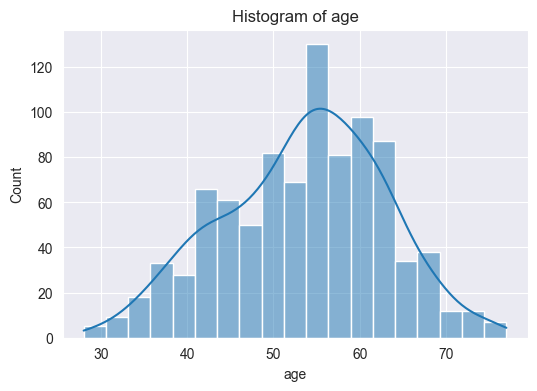

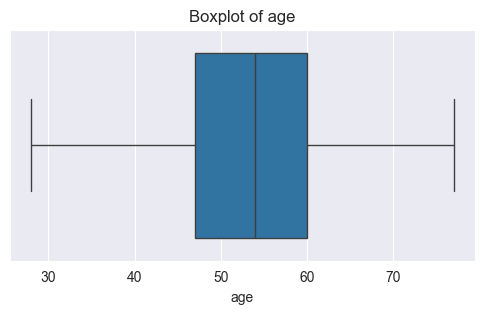

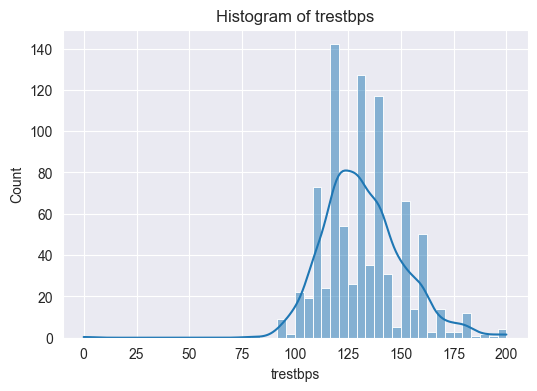

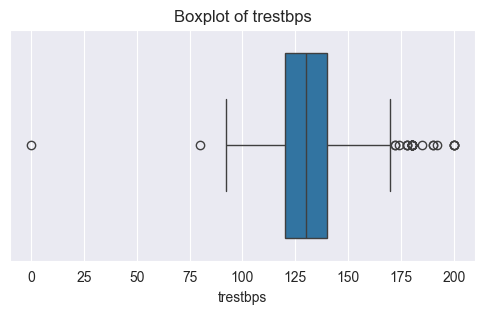

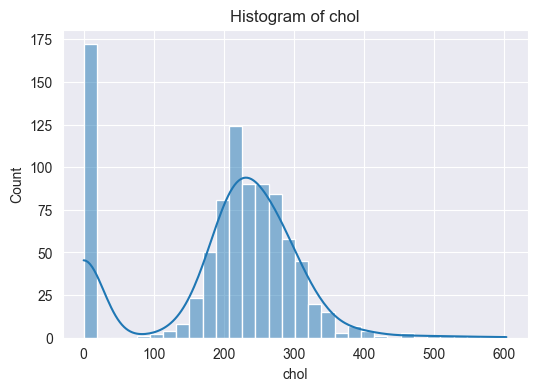

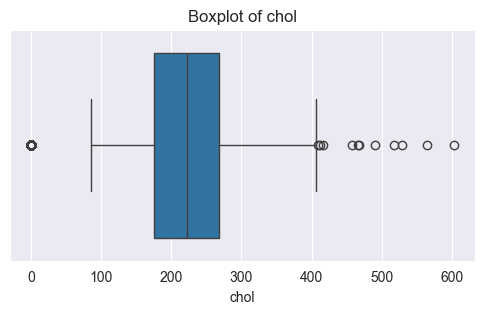

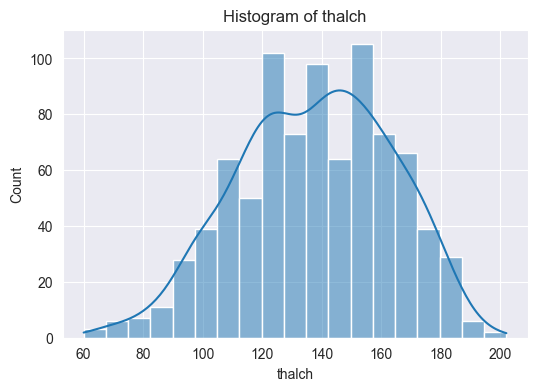

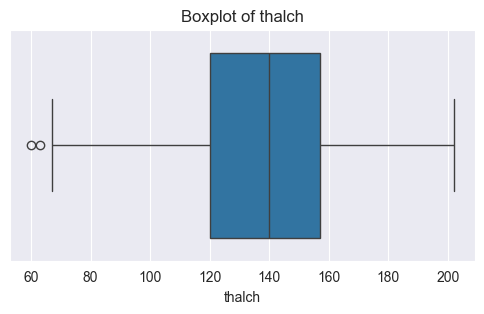

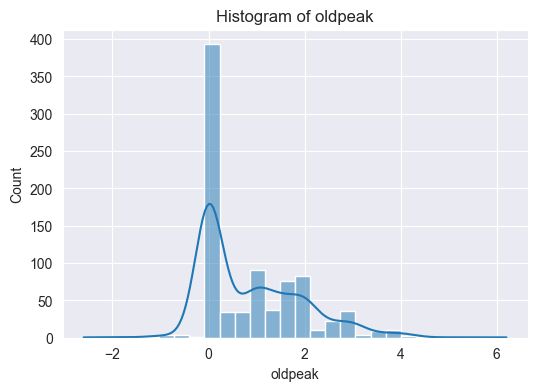

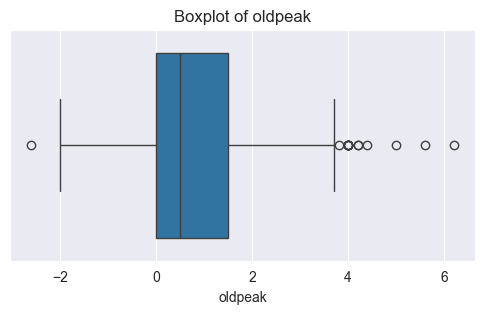

In [20]:

num_cols = ['age','trestbps','chol','thalch','oldpeak']

for c in num_cols:
    if c in df.columns:
        # Histogram
        plt.figure(figsize=(6,4))
        sns.histplot(df[c], kde=True)
        plt.title(f'Histogram of {c}')
        # Save
        plt.savefig(os.path.join(OUT_DIR, f'hist_{c}.png'), bbox_inches='tight')
        plt.show()  # display inline
        plt.close()

        # Boxplot
        plt.figure(figsize=(6,3))
        sns.boxplot(x=df[c])
        plt.title(f'Boxplot of {c}')
        # Save
        plt.savefig(os.path.join(OUT_DIR, f'box_{c}.png'), bbox_inches='tight')
        plt.show()  # display inline
        plt.close()

## Categorical Countplots 

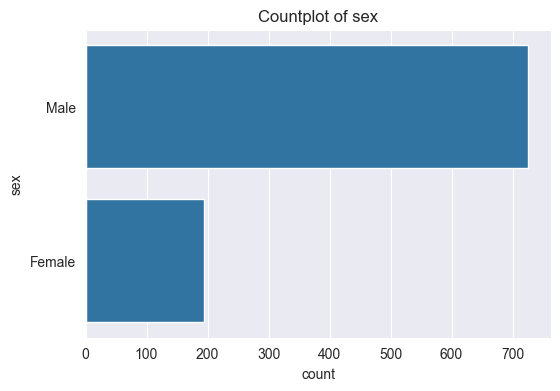

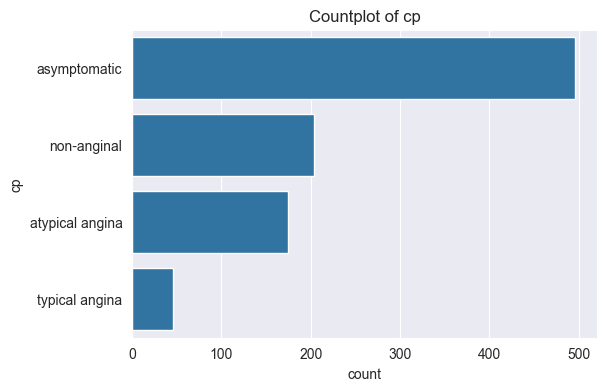

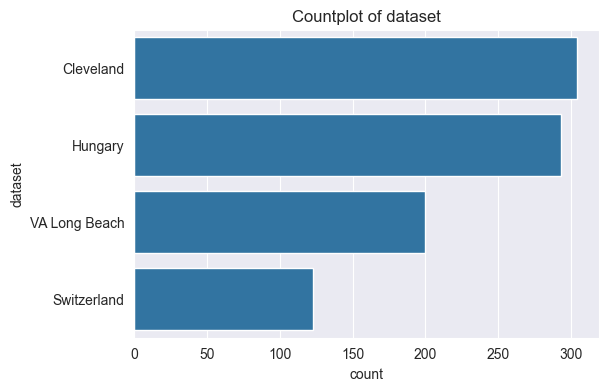

In [21]:
cat_cols = ['sex','cp','dataset']

for c in cat_cols:
    if c in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(y=c, data=df, order=df[c].value_counts().index)
        plt.title(f'Countplot of {c}')
        # Save
        plt.savefig(os.path.join(OUT_DIR, f'count_{c}.png'), bbox_inches='tight')
        plt.show()  # display inline
        plt.close()

## Correlation Heatmap (Numerical Columns)

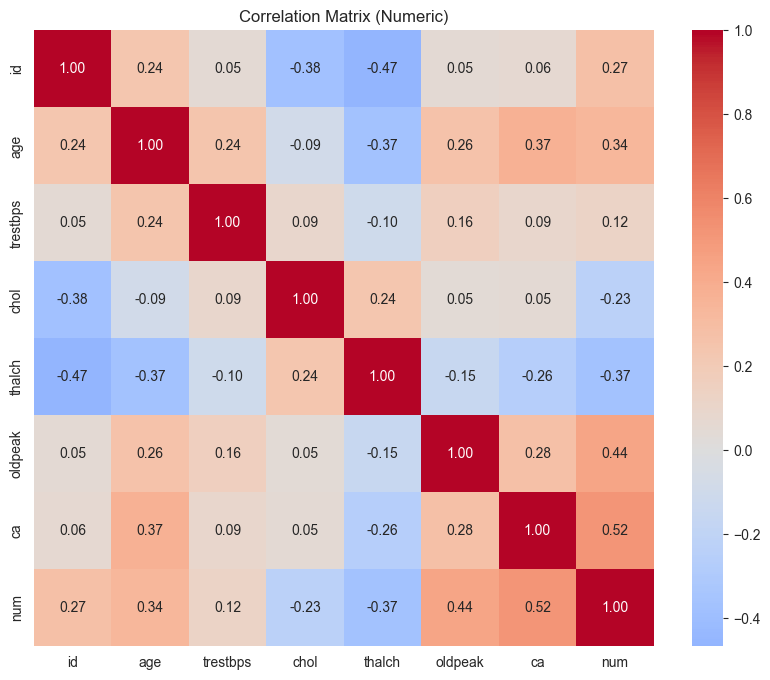

In [22]:
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
cm = num_df.corr()
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numeric)')
# Save
plt.savefig(os.path.join(OUT_DIR, 'corr_heatmap.png'), bbox_inches='tight')
plt.show()  # display inline
plt.close()

## Scatter Plots

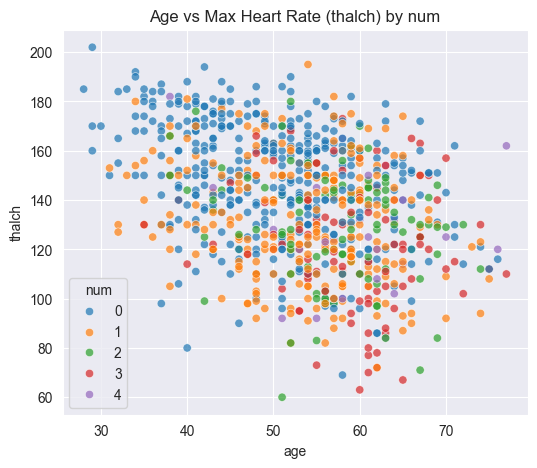

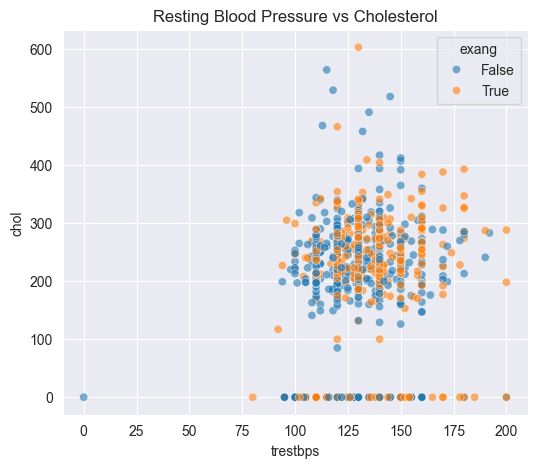

In [23]:
# Age vs Max Heart Rate colored by 'num'
if set(['age','thalch','num']).issubset(df.columns):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x='age', y='thalch', hue='num', palette='tab10', data=df, alpha=0.7)
    plt.title('Age vs Max Heart Rate (thalch) by num')
    plt.savefig(os.path.join(OUT_DIR, 'scatter_age_thalch.png'), bbox_inches='tight')
    plt.show()  # display inline
    plt.close()

# Resting BP vs Cholesterol
if set(['trestbps','chol']).issubset(df.columns):
    plt.figure(figsize=(6,5))
    if 'exang' in df.columns:
        sns.scatterplot(x='trestbps', y='chol', hue='exang', data=df, alpha=0.6)
    else:
        sns.scatterplot(x='trestbps', y='chol', data=df, alpha=0.6)
    plt.title('Resting Blood Pressure vs Cholesterol')
    plt.savefig(os.path.join(OUT_DIR, 'scatter_trestbps_chol.png'), bbox_inches='tight')
    plt.show()  # display inline
    plt.close()

## Pairplot (Sample Subset)

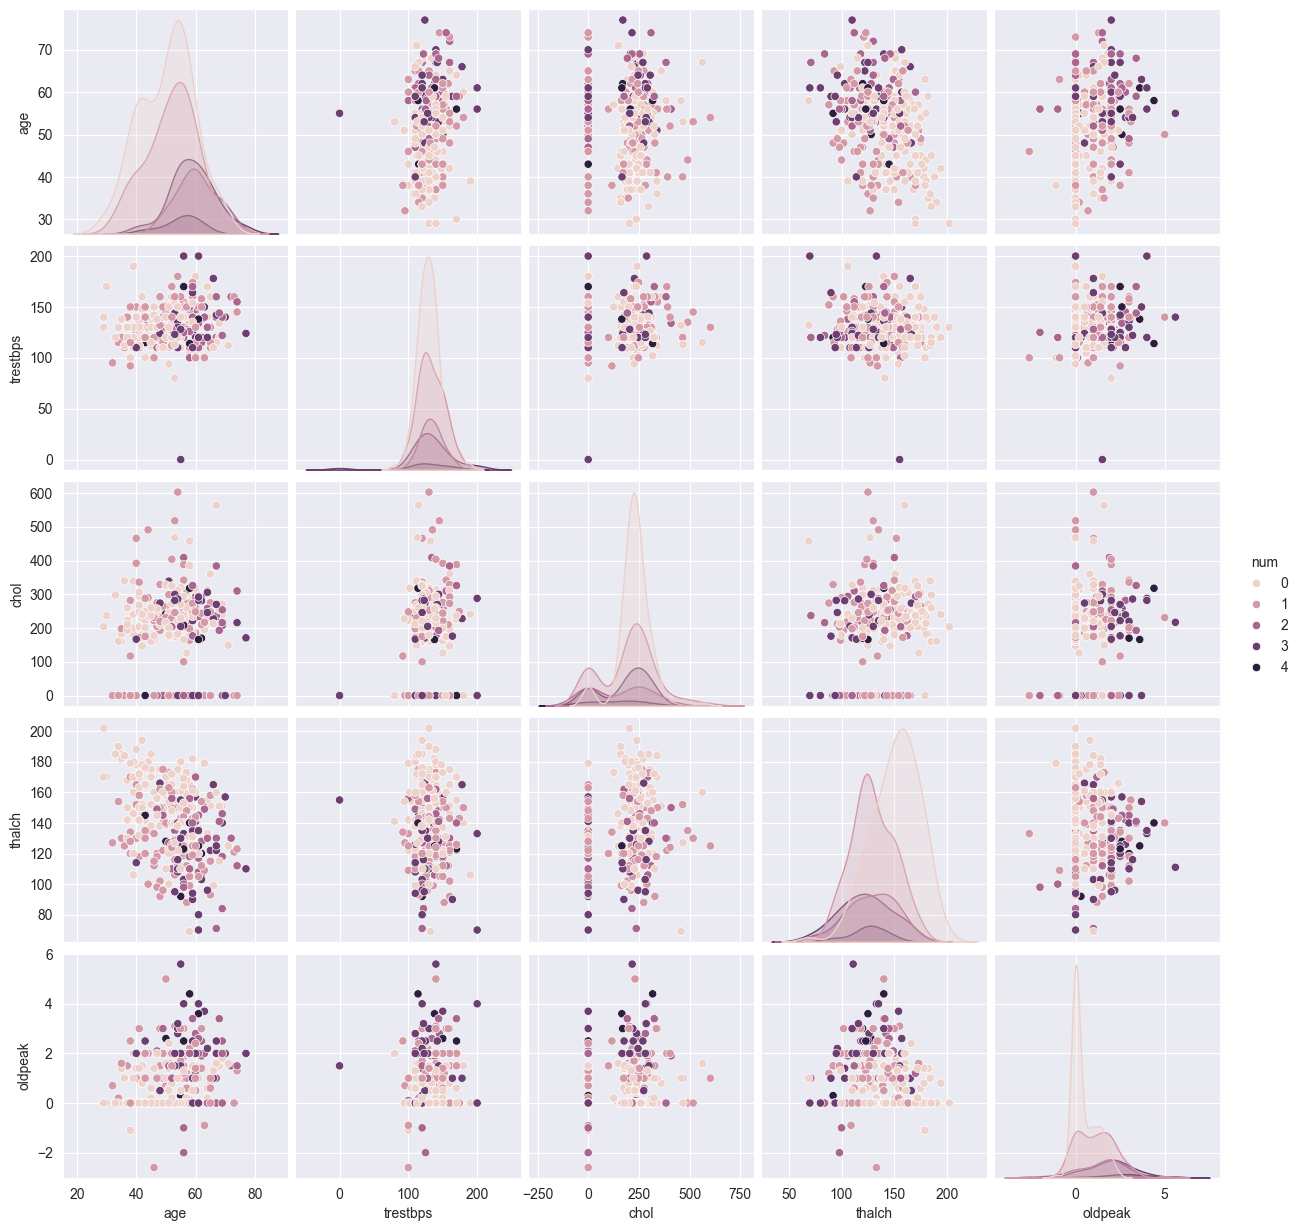

In [24]:
pair_cols = [c for c in ['age','trestbps','chol','thalch','oldpeak','num'] if c in df.columns]

if len(pair_cols) >= 3:
    try:
        sample_df = df[pair_cols].sample(min(300, len(df)))
        pp = sns.pairplot(sample_df, hue='num' if 'num' in pair_cols else None)
        pp.savefig(os.path.join(OUT_DIR, 'pairplot_subset.png'), bbox_inches='tight')
        plt.show()  # display inline
    except Exception as e:
        print('Pairplot skipped due to', e)
